In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [25]:
df=pd.read_csv('superstore_final_dataset.csv', encoding='latin1')

# Data Preparation

### Data Understanding

In [27]:
df.head()

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales
0,1,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/6/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold N Roll Cart System,22.3680


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row_ID         9800 non-null   int64  
 1   Order_ID       9800 non-null   object 
 2   Order_Date     9800 non-null   object 
 3   Ship_Date      9800 non-null   object 
 4   Ship_Mode      9800 non-null   object 
 5   Customer_ID    9800 non-null   object 
 6   Customer_Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal_Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product_ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub_Category   9800 non-null   object 
 16  Product_Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [31]:
df.isnull().sum()

Row_ID            0
Order_ID          0
Order_Date        0
Ship_Date         0
Ship_Mode         0
Customer_ID       0
Customer_Name     0
Segment           0
Country           0
City              0
State             0
Postal_Code      11
Region            0
Product_ID        0
Category          0
Sub_Category      0
Product_Name      0
Sales             0
dtype: int64

In [33]:
df.duplicated().sum()

0

In [35]:
df.shape

(9800, 18)

### Data Cleaning

- We have to change the data types of Order Date and Ship Date

In [42]:
df.columns=df.columns.str.lower()

In [48]:
df['order_date']=pd.to_datetime(df['order_date'],format='%d/%m/%Y')
df['ship_date']=pd.to_datetime(df['ship_date'],format='%d/%m/%Y')

In [52]:
df['postal_code']=df['postal_code'].fillna(df['postal_code'].median())

In [57]:
df.columns

Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'country', 'city', 'state',
       'postal_code', 'region', 'product_id', 'category', 'sub_category',
       'product_name', 'sales'],
      dtype='object')

### Feature Engineering

In [60]:
df['order_year']=df['order_date'].dt.year

In [62]:
df['order_month'] = df['order_date'].dt.month_name()

In [64]:
df['month_num'] = df['order_date'].dt.month

In [66]:
df['quarter'] = df['order_date'].dt.quarter

In [68]:
df['day_of_week'] = df['order_date'].dt.day_name()

In [70]:
# Shipping Days

df['shipping_days']= (
    df['ship_date'] - df['order_date']
).dt.days

In [72]:
# Sales Segment
df['sales_segment']=pd.qcut(
    df['sales'],
    q=3,
    labels=['Low Sales','Medium Sales','High Sales']
)

In [74]:
df[['order_year',
    'order_month',
    'month_num',
    'quarter',
    'day_of_week',
    'shipping_days',
    'sales_segment']].head()

,order_year,order_month,month_num,quarter,day_of_week,shipping_days,sales_segment
0,2017,November,11,4,Wednesday,3,High Sales
1,2017,November,11,4,Wednesday,3,High Sales
2,2017,June,6,2,Monday,4,Low Sales
3,2016,October,10,4,Tuesday,7,High Sales
4,2016,October,10,4,Tuesday,7,Low Sales


In [78]:
df['shipping_days'].describe().T

count    9800.000000
mean        3.961122
std         1.749614
min         0.000000
25%         3.000000
50%         4.000000
75%         5.000000
max         7.000000
Name: shipping_days, dtype: float64

#### Shipping Insights
- Average Shipping Time = 3.96 days
- Median Shipping Time = 4 days
- Fastest Delivery = 0 days
- Slowest Delivery = 7 days

# KPI Analysis

### KPI 1: Total Sales

In [93]:
total_sales=df['sales'].sum()
print(f'Total Sales: ${total_sales:,.2f}')

Total Sales: $2,261,536.78


### KPI 2: Total Orders

In [97]:
total_orders=df['order_id'].nunique()
print("Total Orders:", total_orders)

Total Orders: 4922


### KPI 3: Unique Customers

In [99]:
unique_customers = df['customer_id'].nunique()
print("Unique Customers:", unique_customers)

Unique Customers: 793


### KPI 4: Average Order Value (AOV)

In [101]:
aov = df['sales'].sum() / df['order_id'].nunique()
print(f"AOV: ${aov:,.2f}")

AOV: $459.48


### KPI 5: Average Shipping Days

In [103]:
avg_shipping = df['shipping_days'].mean()
print(f"Average Shipping Days: {avg_shipping:.2f}")

Average Shipping Days: 3.96


### Quick Insights

**Insight 1**
The business generated over $2.26 million in sales.

**Insight 2**
The company served 793 unique customers.

**Insight 3**
Nearly 4,922 orders were processed.

**Insight 4**
The average customer order value is approximately $459, indicating moderate transaction sizes.

**Insight 5**
Orders are fulfilled in approximately 4 days, suggesting an efficient shipping process.

# Sales Performance Analysis(Trends)

### 1. Monthly Sales Trend ⭐

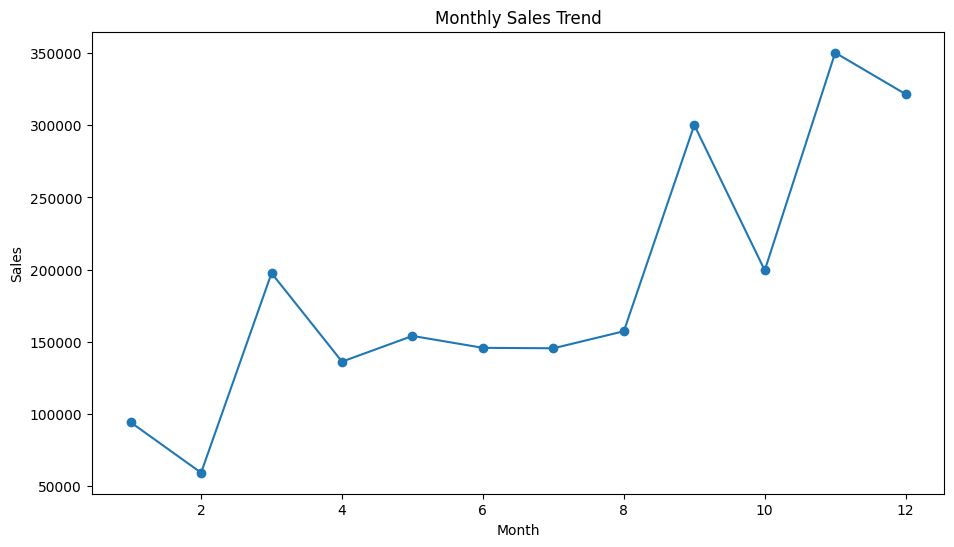

In [116]:
monthly_sales = df.groupby('month_num')['sales'].sum().reset_index()

plt.figure(figsize=(11,6))
plt.plot(monthly_sales['month_num'],
         monthly_sales['sales'],
         marker='o')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.show()

### Executive Summary: Monthly Sales Trend Performance

* **Highest Sales Month:** Sales peaked dramatically in **November (Month 11)**, reaching the highest point of the year at approximately **350,000 transactions**.
* **Lowest Sales Month:** Performance hit its absolute lowest trough early in the year during **February (Month 2)**, dropping to approximately **59,000 transactions**.
* **Seasonal Sales Growth:** The business experiences a massive upward surge in transaction volume during the latter half of the year. While the first eight months maintain a lower baseline fluctuating between 59,000 and 200,000 sales, a powerful macro expansion begins in September and carries through the holiday season, keeping late-year volume consistently above the 200,000 mark.

### 2. Quarterly Sales Performance

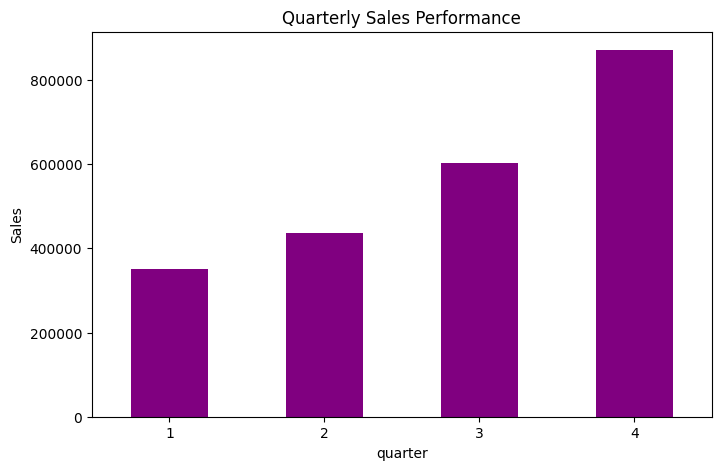

In [130]:
quarterly_sales = df.groupby('quarter')['sales'].sum()

quarterly_sales.plot(
    kind='bar',
    figsize=(8,5),
    color='purple'
)

plt.title('Quarterly Sales Performance')
plt.ylabel('Sales')
plt.xticks(rotation=0)
plt.show()

### Executive Summary: Quarterly Sales Performance

* **Strongest Quarter:** Sales surged dramatically to their absolute peak in **Quarter 4 (Q4)**, closing out the year with a massive volume of approximately **870,000 sales**.
* **Weakest Quarter:** The start of the fiscal year served as the lowest-performing period, with **Quarter 1 (Q1)** recording the weakest volume at approximately **350,000 sales**.
* **Compounding Growth Trend:** The chart reveals a textbook sequential growth pattern. Sales expand aggressively quarter-over-quarter without a single dip, accelerating from Q1 (~350k) through Q2 (~435k) and Q3 (~600k), culminating in the explosive holiday-driven peak of Q4.

### Sales by Region

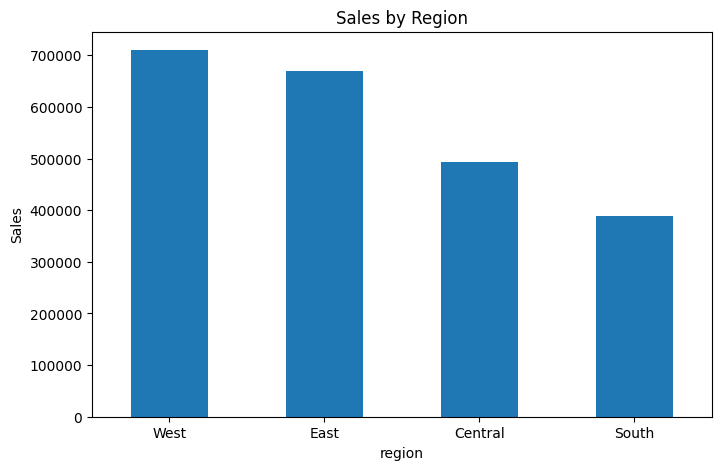

In [138]:
region_sales=df.groupby('region')['sales'].sum().sort_values(ascending=False)
region_sales.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Sales by Region')
plt.ylabel('Sales')
plt.xticks(rotation=0)
plt.show()

### Executive Summary: Sales Performance by Region

* **Highest Performing Region:** The **West** region stands out as the primary volume driver, leading the company with a peak of approximately **710,000 sales**.
* **Lowest Performing Region:** The **South** region serves as the weakest market territory, recording the lowest transaction volume at approximately **390,000 sales**.
* **Regional Distribution Gradient:** A clear downward performance trend is visible moving from west to east across the chart. While coastal territories dominate (with West and East combining for well over 1.3 million sales), volume contracts substantially as you head inland to Central (~495,000 sales) and bottoms out entirely in the South.

# State Analysis

### Top 10 States by Sales

In [148]:
top_states=(df.groupby('state')['sales']
        .sum()
        .sort_values(ascending=False)
        .head(10)
    )
top_states

state
California      446306.4635
New York        306361.1470
Texas           168572.5322
Washington      135206.8500
Pennsylvania    116276.6500
Florida          88436.5320
Illinois         79236.5170
Michigan         76136.0740
Ohio             75130.3500
Virginia         70636.7200
Name: sales, dtype: float64

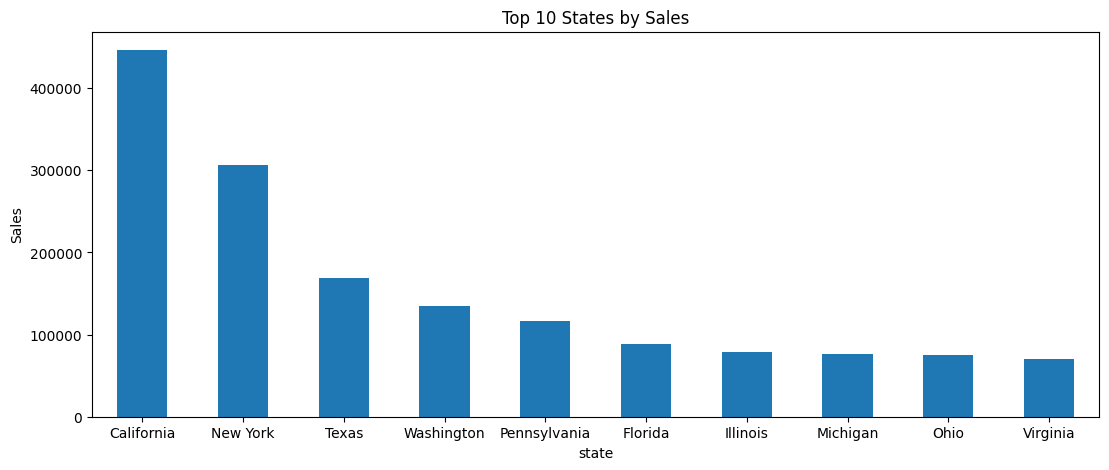

In [160]:
plt.figure(figsize=(13,5))
top_states.plot(kind='bar')

plt.title('Top 10 States by Sales')
plt.ylabel('Sales')
plt.xticks(rotation=0)
plt.show()

### Executive Summary: Top 10 States by Sales

* **Dominant Market Leader:** **California** stands out as the absolute powerhouse for the business, driving the highest volume with approximately **445,000 sales**.
* **Secondary Anchor:** **New York** holds a secure position as the second-strongest market, generating a significant volume of approximately **305,000 sales**.
* **The Long Tail Plateau:** After a steep drop-off from the top two giants to **Texas** (~170,000 sales), the distribution flattens into a steady baseline. The lower half of the chart—comprising **Florida, Illinois, Michigan, Ohio, and Virginia**—displays high stability, with each state consistently contributing between **70,000 and 90,000 sales**.

### Bottom 10 States by Sales

In [163]:
bottom_states = (
    df.groupby('state')['sales']
      .sum()
      .sort_values(ascending=True)
      .head(10)
)

bottom_states

state
North Dakota             919.910
West Virginia           1209.824
Maine                   1270.530
South Dakota            1315.560
Wyoming                 1603.136
District of Columbia    2865.020
Kansas                  2914.310
Idaho                   4382.486
Iowa                    4443.560
New Mexico              4783.522
Name: sales, dtype: float64

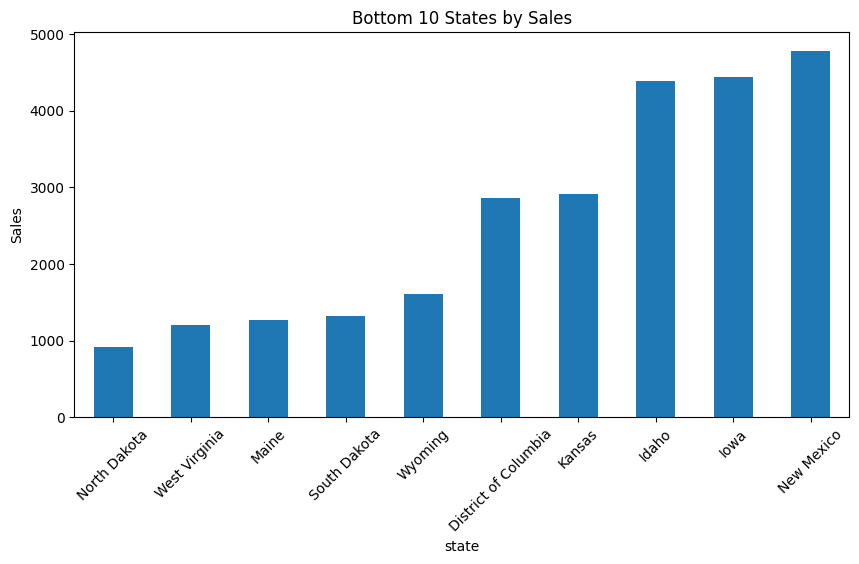

In [165]:
plt.figure(figsize=(10,5))
bottom_states.plot(kind='bar')

plt.title('Bottom 10 States by Sales')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.show()

### Executive Summary: Bottom 10 States by Sales

* **Absolute Lowest Performing Market:** **North Dakota** anchors the bottom of the list, serving as the weakest individual market with a volume of approximately **900 sales**.
* **The Low-Volume Baseline:** The first four states—**North Dakota, West Virginia, Maine, and South Dakota**—show severe stagnation, with each territory struggling to cross the tiny threshold of **1,300 sales**.
* **Stepped Growth Gradient:** Unlike a flat baseline, the bottom tier reveals a distinct upward stair-step pattern. Volume climbs incrementally through Wyoming, hits a mid-level plateau around **District of Columbia and Kansas** (~2,900 sales), and steps up again toward the top of this lower bracket where **New Mexico** leads the group at approximately **4,800 sales**.

# Category Analysis

### Analysis 1: Sales by Category

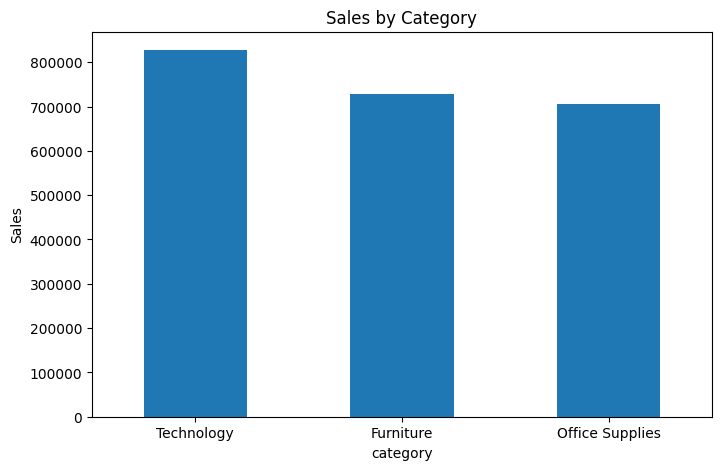

In [170]:
category_sales = (
    df.groupby('category')['sales']
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))
category_sales.plot(kind='bar')

plt.title('Sales by Category')
plt.ylabel('Sales')
plt.xticks(rotation=0)
plt.show()

### Executive Summary: Sales Performance by Category

* **Highest Performing Category:** **Technology** stands out as the primary volume driver, leading all segments with a peak of approximately **825,000 sales**.
* **Lowest Performing Category:** **Office Supplies** serves as the lowest-performing segment, recording approximately **705,000 sales**.
* **Even Distribution (No Concentration):** Revenue and transaction volume are **not** concentrated in a single category. Instead, the market displays exceptional balance across all three operational pillars, with **Furniture** holding the middle ground at roughly **728,000 sales**. The narrow variance window of approximately 14% between the highest and lowest performers highlights a highly diversified, healthy product ecosystem that does not rely on a lone flagship sector to sustain itself.

### Analysis 2: Sales by Sub-Category

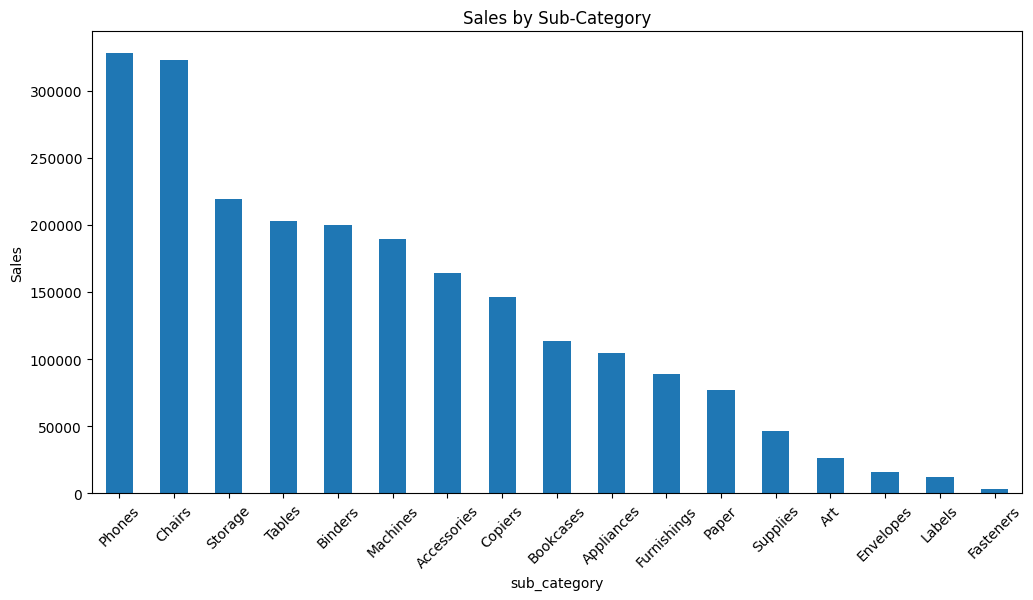

In [174]:
subcategory_sales = (
    df.groupby('sub_category')['sales']
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))
subcategory_sales.plot(kind='bar')

plt.title('Sales by Sub-Category')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.show()

### Executive Summary: Sales Performance by Sub-Category

* **Top-Performing Sub-Category:** **Phones** emerges as the premier revenue anchor, driving the absolute highest volume with approximately **330,000 sales**, closely rivaled by **Chairs** at roughly **324,000 sales**.
* **Lowest-Performing Sub-Category:** **Fasteners** anchors the absolute bottom of the performance list, registering as the weakest catalog segment with approximately **3,000 sales**.
* **Highly Skewed Revenue Distribution:** Revenue is heavily top-weighted, exhibiting a classic long-tail Pareto distribution pattern. The top five segments (**Phones, Chairs, Storage, Tables, and Binders**) act as the core engine, generating an overwhelming majority of total revenue. Past **Accessories**, volume drops off sharply in a steady downward cascade, flattening out entirely into a low-yield plateau where minor accessory lines like **Envelopes, Labels, and Fasteners** contribute negligible amounts to overall business volume.

# Product Analysis

### Top 10 Products by Sales

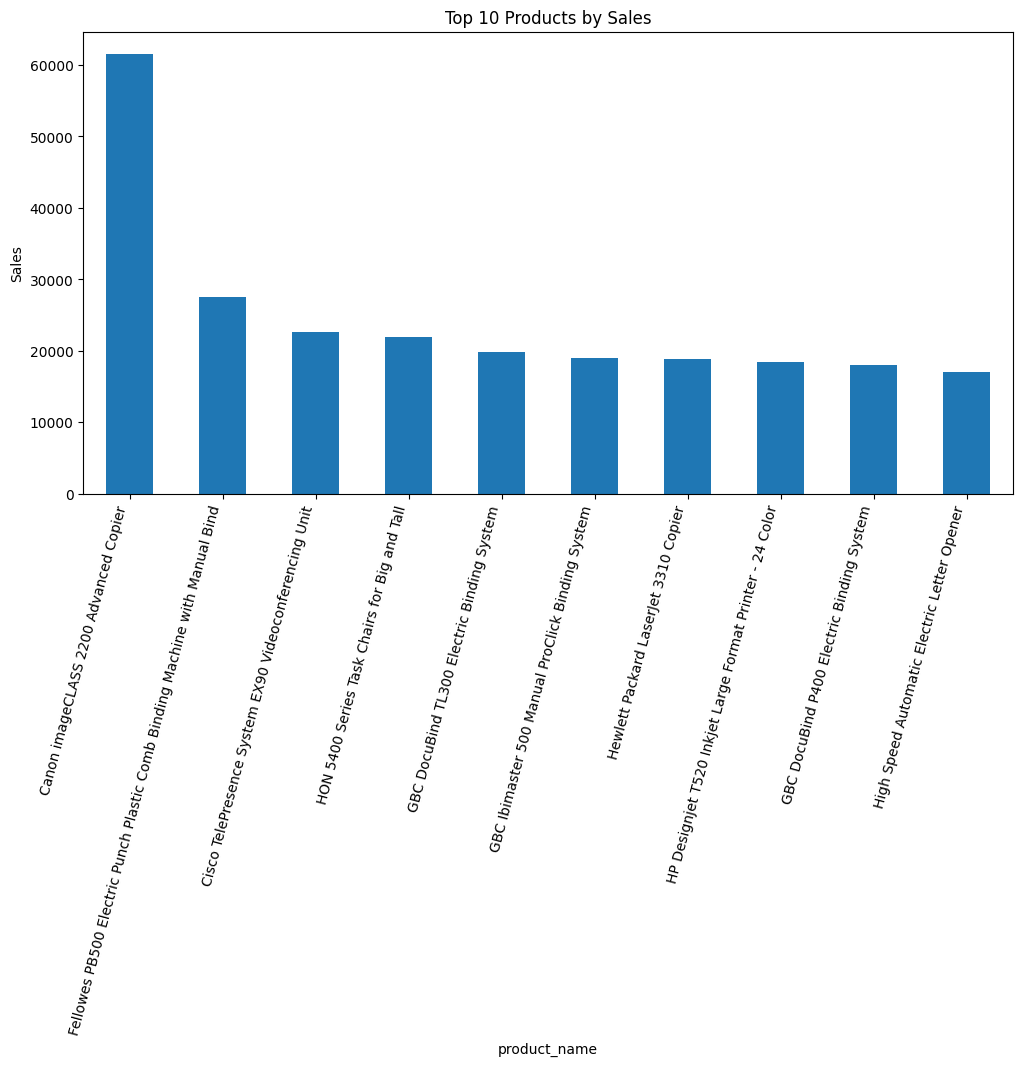

<Figure size 640x480 with 0 Axes>

In [185]:
top_products = (
    df.groupby('product_name')['sales']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))
top_products.plot(kind='bar')
plt.title('Top 10 Products by Sales')
plt.ylabel('Sales')
plt.xticks(rotation=75,ha='right')
plt.show()
plt.savefig('graph1.png')

In [187]:
top_products

product_name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24 Color                       18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: sales, dtype: float64

### Executive Summary: Top Products by Sales

* **Dominant Revenue Leader:** The **Canon imageCLASS 2200 Advanced Copier** stands out as the single most powerful revenue driver in the inventory, generating a massive sales volume of approximately **61,600**. It completely outclasses all other items, bringing in more than double the revenue of the next closest product.
* **Secondary Tier Anchors:** High-value workplace infrastructure and tech items fill the next tier, anchored by the **Fellowes PB500 Electric Binding Machine** (roughly **27,450**) and the **Cisco TelePresence System EX90** (roughly **22,638**). 
* **The High-Yield Baseline:** Beyond the top three products, the remaining list flattens out into a remarkably steady revenue plateau. Products ranging from the **HON 5400 Series Task Chairs** down to the **High Speed Automatic Electric Letter Opener** exhibit tight consistency, with each item contributing a solid baseline between **17,000 and 21,900** to overall sales.

### Bottom 10 Products by Sales

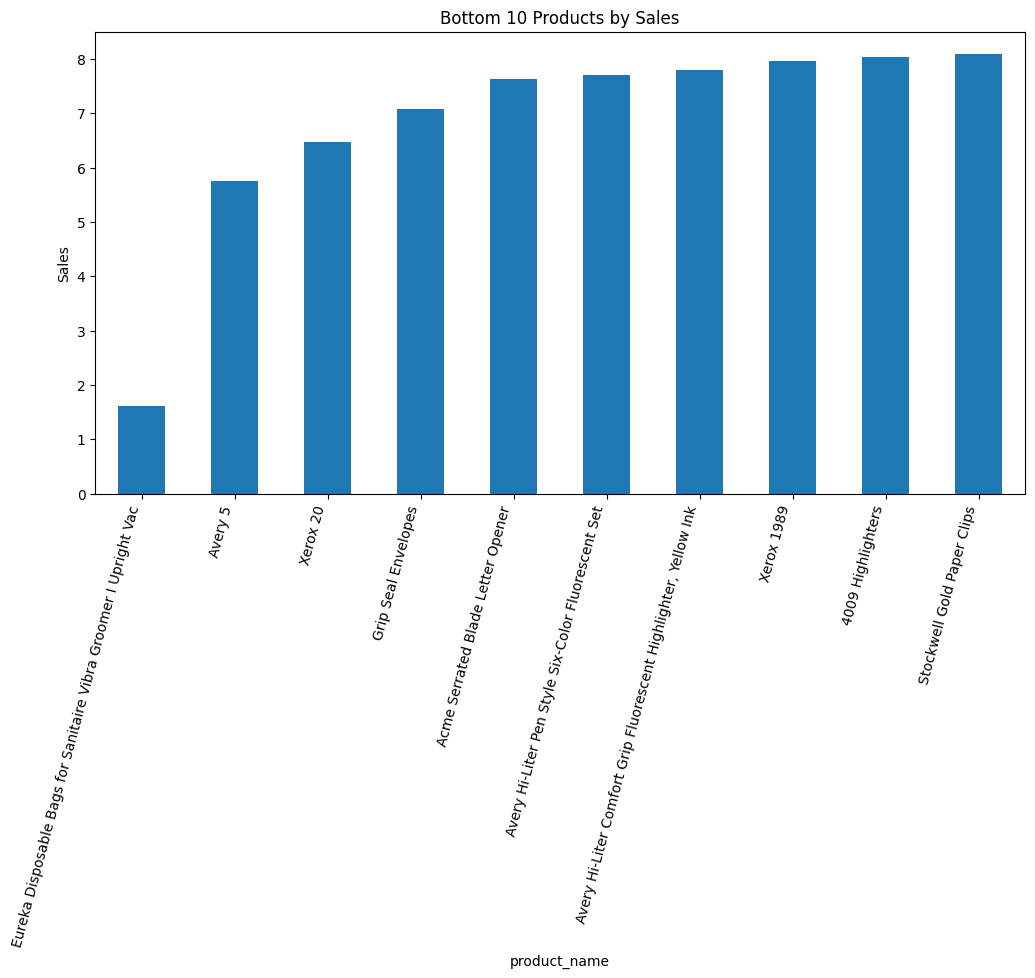

In [192]:
bottom_products = (
    df.groupby('product_name')['sales']
      .sum()
      .sort_values(ascending=True)
      .head(10)
)

plt.figure(figsize=(12,6))
bottom_products.plot(kind='bar')
plt.title('Bottom 10 Products by Sales')
plt.ylabel('Sales')
plt.xticks(rotation=75,ha='right')
plt.show()

In [194]:
bottom_products

product_name
Eureka Disposable Bags for Sanitaire Vibra Groomer I Upright Vac    1.624
Avery 5                                                             5.760
Xerox 20                                                            6.480
Grip Seal Envelopes                                                 7.072
Acme Serrated Blade Letter Opener                                   7.632
Avery Hi-Liter Pen Style Six-Color Fluorescent Set                  7.700
Avery Hi-Liter Comfort Grip Fluorescent Highlighter, Yellow Ink     7.800
Xerox 1989                                                          7.968
4009 Highlighters                                                   8.040
Stockwell Gold Paper Clips                                          8.096
Name: sales, dtype: float64

### Executive Summary: Bottom Products by Sales

* **Absolute Weakest Revenue Generator:** The **Eureka Disposable Bags for Sanitaire Vibra Groomer I Upright Vac** sits at the absolute bottom of the entire inventory, contributing a negligible sales value of approximately **1.62**.
* **Micro-Yield Core:** The bottom tier consists almost entirely of low-cost, transactional office consumables. Items like **Avery 5**, **Xerox 20**, and **Grip Seal Envelopes** anchor the lowest performance index, struggling to generate more than **5.70 to 7.10** in total sales volume.
* **Low-Value Consolidation Plateau:** Past the absolute bottom vacuum bags, the remaining low-performing products consolidate into an incredibly tight, flat baseline. Products ranging from the **Acme Letter Opener** up to the **Stockwell Gold Paper Clips** stall entirely within a micro-window between **7.60 and 8.10**, signaling highly stagnant demand or extremely low unit pricing across minor supply lines.

# Customer Segment Analysis

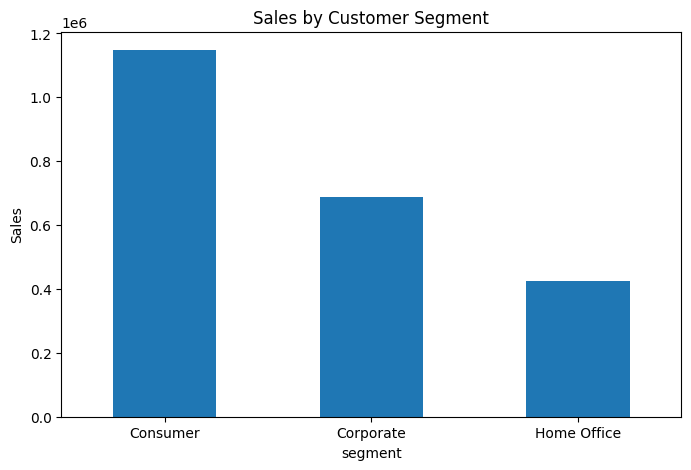

In [199]:
segment_sales = (
    df.groupby('segment')['sales']
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))
segment_sales.plot(kind='bar')

plt.title('Sales by Customer Segment')
plt.ylabel('Sales')
plt.xticks(rotation=0)
plt.show()

### Executive Summary: Sales Performance by Customer Segment

* **Highest Revenue Segment:** The **Consumer** segment stands out as the absolute powerhouse for the business, driving the highest volume with an impressive total of approximately **1.15 million sales**. 
* **Lowest Revenue Segment:** The **Home Office** division represents the smallest market segment, anchoring the lower end of production at approximately **425,000 sales**.
* **Tiered Revenue Distribution:** Sales exhibit a clear, step-down distribution across the three core pillars. The dominant Consumer sector generates nearly triple the volume of the Home Office tier, while the **Corporate** sector securely holds the middle ground, contributing a substantial baseline of approximately **690,000 sales**. This gradient highlights that B2C retail remains the foundational engine of business growth, with commercial and remote-work channels functioning as secondary streams.

# Shipping Mode Analysis

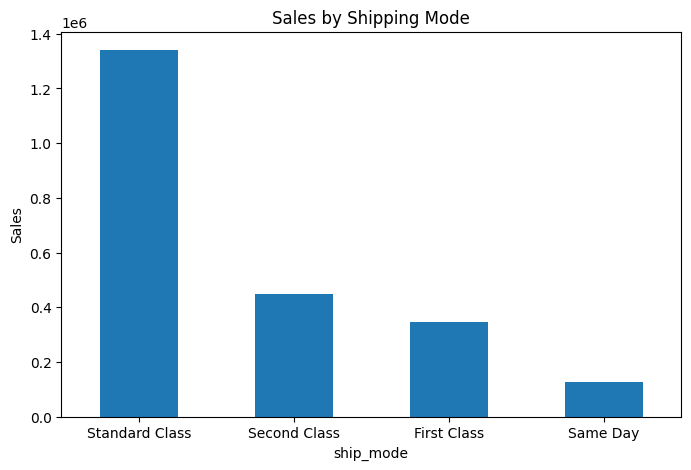

In [203]:
shipmode_sales = (
    df.groupby('ship_mode')['sales']
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))
shipmode_sales.plot(kind='bar')

plt.title('Sales by Shipping Mode')
plt.ylabel('Sales')
plt.xticks(rotation=0)
plt.show()

### Executive Summary: Sales Performance by Shipping Mode

* **Highest Sales Shipping Mode:** **Standard Class** stands out as the undisputed leader, driving a massive sales volume of approximately **1.35 million**.
* **Lowest Sales Shipping Mode:** **Same Day** delivery represents the smallest fulfillment segment, anchoring the low end of the chart at approximately **128,000 sales**.
* **Clear Customer Shipping Preferences:** The data reveals a powerful, heavily skewed preference gradient. The vast majority of buyers completely consolidate around economy tier fulfillment, with **Second Class** (~450,000 sales) and **First Class** (~350,000 sales) serving as secondary mid-tier alternatives.
* **Cost-Efficiency vs. Speed:** Customers overwhelmingly favor **cost-efficiency over speed**. Standard economy options dominate the fulfillment landscape, while premium, high-velocity choices like Same Day logistics capture only a micro-fraction of total orders. This indicates that price sensitivity or a lack of delivery urgency heavily influences purchasing choices across the user base.

In [210]:
df.to_csv('sales_performance_analysis.csv',index=False)

# Conclusion

This Sales Performance Analysis project examined 9,800 retail transactions to evaluate business performance across products, customer segments, regions, states, and shipping methods. Through data cleaning, feature engineering, KPI analysis, and exploratory data analysis, valuable insights were uncovered regarding revenue drivers and customer purchasing behavior.

The analysis revealed that the business generated over **$2.26 million** in total sales from **4,922 orders** across **793 unique customers**, with an average order value of **$459.48**. Sales demonstrated strong seasonality, with **November emerging as the highest-performing month** and **Q4 contributing the largest share of annual revenue**, indicating the importance of year-end demand.

From a geographic perspective, the **West region** and **California** emerged as the strongest revenue-generating markets, while several smaller states contributed only a minimal share of sales. Product analysis showed that **Technology** was the leading category, with **Phones** serving as the highest-performing sub-category. Additionally, the **Canon imageCLASS 2200 Advanced Copier** was identified as the single largest revenue-generating product in the inventory.

Customer analysis highlighted the **Consumer segment** as the primary business driver, contributing more than half of total sales. Shipping analysis further revealed a strong customer preference for **Standard Class delivery**, suggesting that customers prioritize affordability and reliability over premium delivery speed.

Overall, the business demonstrates a diversified and stable sales structure with strong growth potential. By strengthening high-performing product categories, expanding successful regional markets, improving underperforming product lines, and leveraging seasonal demand patterns, the company can further enhance revenue growth and operational efficiency.

This analysis provides actionable insights that can support data-driven decision-making, strategic planning, inventory optimization, and customer-focused business growth initiatives.